# Student Performance: A Data Story in Three Visualizations

This notebook presents an initial data storytelling proposal based on `student_cleaned.csv`. Instead of showing every possible relationship, the visualizations follow one question:

> **What do the data suggest about student performance, and where might academic support be most useful?**

The story moves from the general result to behavioral patterns and then to a possible support opportunity. The findings describe associations in this dataset and should not be interpreted as causal effects.

## Setup

The libraries are imported once, and the pass threshold is defined as a final exam score of 60 or higher.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titleweight": "bold",
    "axes.titlesize": 15,
    "axes.labelsize": 11,
    "font.family": "DejaVu Sans",
})

BLUE = "#246B8E"
ORANGE = "#E07A3F"
GOLD = "#E9B44C"
DARK = "#19323C"
LIGHT = "#EAF1F4"
PASS_THRESHOLD = 60

In [2]:
df = pd.read_csv("student_cleaned.csv")
df["Passed"] = df["Final_Exam_Score"] >= PASS_THRESHOLD

print(f"Students: {len(df):,}")
print(f"Average final score: {df['Final_Exam_Score'].mean():.1f}")
print(f"Pass rate: {df['Passed'].mean():.1%}")

Students: 6,607
Average final score: 60.4
Pass rate: 52.2%


## Visualization 1 - The Overall Picture

### Only a small majority of students pass

The first chart establishes the situation. The average score is very close to the passing threshold, and many students are concentrated around that line. This means that relatively small differences in performance can change the final outcome for a large group of students.

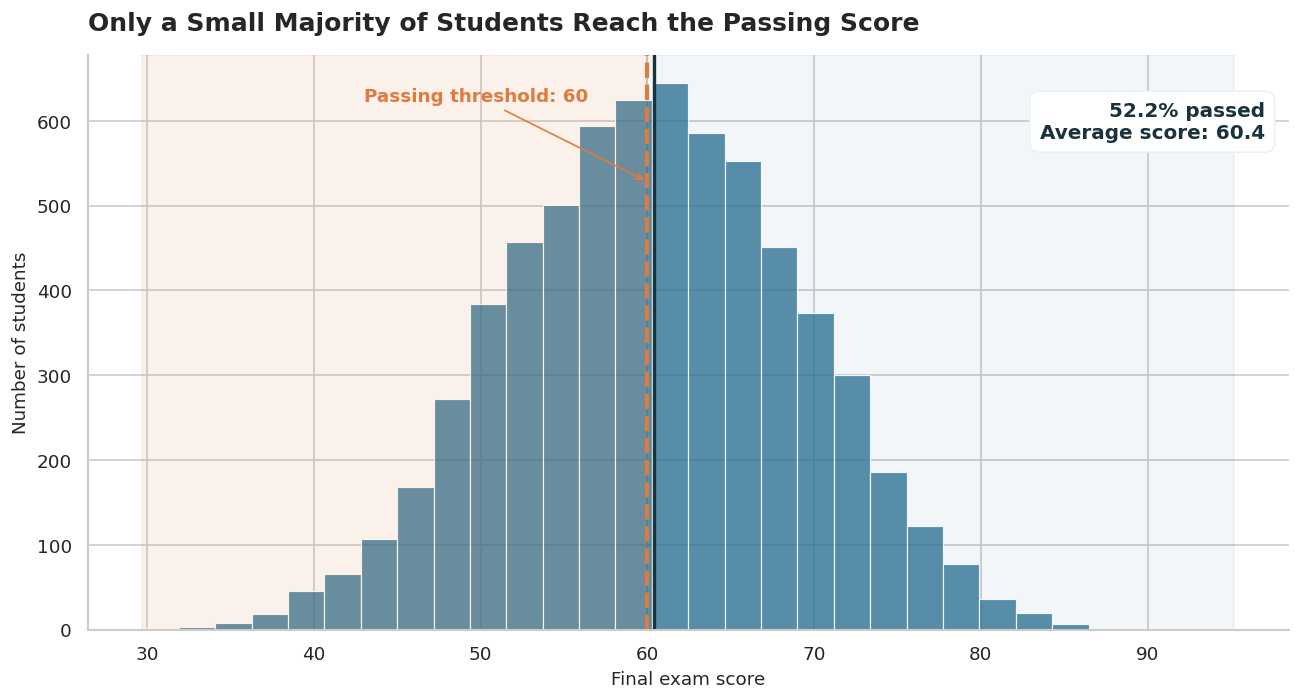

In [3]:
scores = df["Final_Exam_Score"]
mean_score = scores.mean()
pass_rate = df["Passed"].mean()

fig, ax = plt.subplots(figsize=(11, 6))

sns.histplot(
    scores,
    bins=30,
    color=BLUE,
    edgecolor="white",
    linewidth=0.7,
    ax=ax,
)

ax.axvspan(scores.min(), PASS_THRESHOLD, color=ORANGE, alpha=0.10)
ax.axvspan(PASS_THRESHOLD, scores.max(), color=BLUE, alpha=0.06)
ax.axvline(PASS_THRESHOLD, color=ORANGE, linewidth=2.5, linestyle="--")
ax.axvline(mean_score, color=DARK, linewidth=2)

ax.annotate(
    f"Passing threshold: {PASS_THRESHOLD}",
    xy=(PASS_THRESHOLD, ax.get_ylim()[1] * 0.78),
    xytext=(PASS_THRESHOLD - 17, ax.get_ylim()[1] * 0.92),
    arrowprops={"arrowstyle": "->", "color": ORANGE},
    color=ORANGE,
    fontsize=11,
    fontweight="bold",
)
ax.text(
    0.98,
    0.92,
    f"{pass_rate:.1%} passed\nAverage score: {mean_score:.1f}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=12,
    fontweight="bold",
    color=DARK,
    bbox={"boxstyle": "round,pad=0.5", "facecolor": "white", "edgecolor": LIGHT},
)

ax.set_title("Only a Small Majority of Students Reach the Passing Score", loc="left", pad=15)
ax.set_xlabel("Final exam score")
ax.set_ylabel("Number of students")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Story point:** The overall result is balanced on a narrow margin: **52.2%** of students pass, while the average score is **60.4**, almost exactly the chosen passing score.

## Visualization 2 - The Behavioral Pattern

### Study time and attendance reinforce each other

Looking at study hours or attendance separately gives only part of the picture. The next chart groups both variables into four equally sized bands and shows the pass rate for each combination.

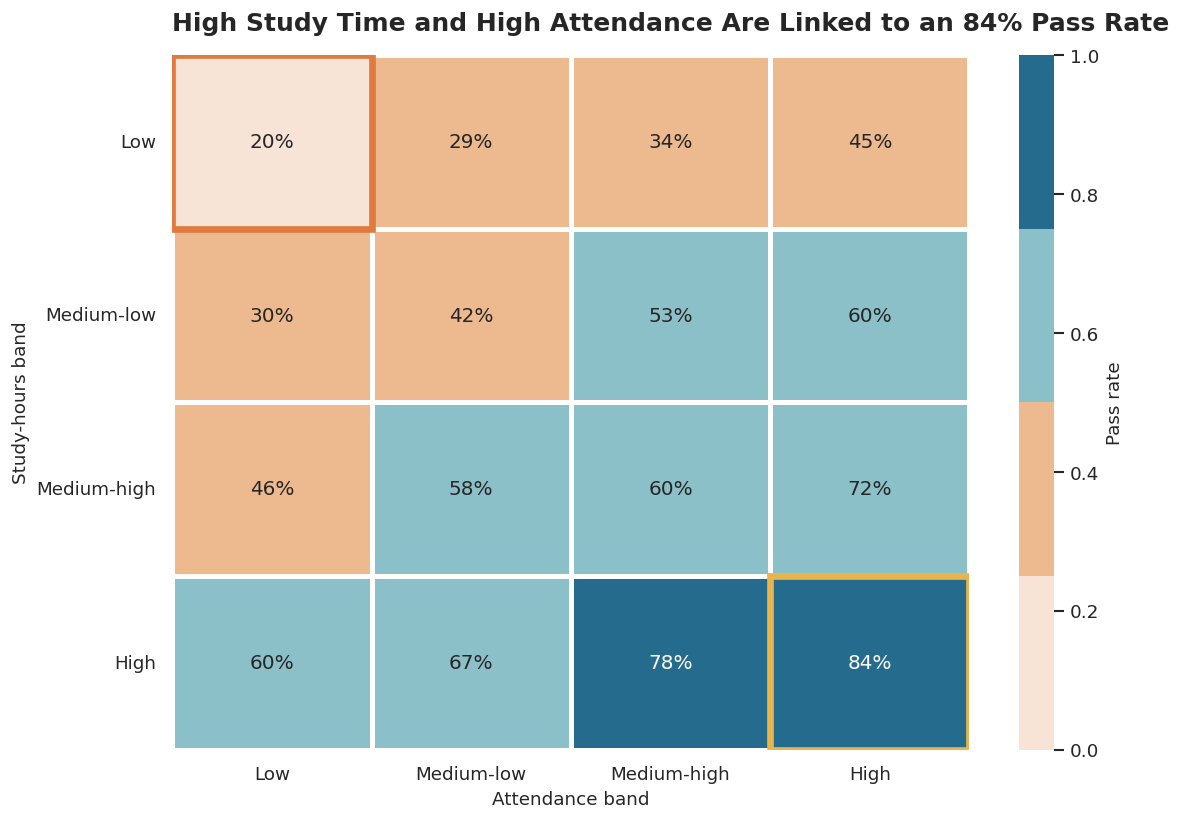

In [4]:
band_order = ["Low", "Medium-low", "Medium-high", "High"]

df["Study_Band"] = pd.qcut(
    df["Hours_Studied"],
    q=4,
    labels=band_order,
)
df["Attendance_Band"] = pd.qcut(
    df["Attendance"],
    q=4,
    labels=band_order,
)

pass_rate_matrix = pd.pivot_table(
    df,
    values="Passed",
    index="Study_Band",
    columns="Attendance_Band",
    aggfunc="mean",
    observed=True,
).reindex(index=band_order, columns=band_order)

fig, ax = plt.subplots(figsize=(10, 7))

sns.heatmap(
    pass_rate_matrix,
    annot=True,
    fmt=".0%",
    cmap=sns.color_palette(["#F7E4D7", "#EDB98F", "#8CC0C8", "#246B8E"], as_cmap=True),
    vmin=0,
    vmax=1,
    linewidths=2,
    linecolor="white",
    cbar_kws={"label": "Pass rate"},
    ax=ax,
)

ax.add_patch(plt.Rectangle((3, 3), 1, 1, fill=False, edgecolor=GOLD, linewidth=4))
ax.add_patch(plt.Rectangle((0, 0), 1, 1, fill=False, edgecolor=ORANGE, linewidth=4))

ax.set_title("High Study Time and High Attendance Are Linked to an 84% Pass Rate", loc="left", pad=15)
ax.set_xlabel("Attendance band")
ax.set_ylabel("Study-hours band")
ax.tick_params(axis="x", rotation=0)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()

**Story point:** The pass rate rises from about **20%** among students in the lowest study and attendance bands to about **84%** among those in the highest bands. The combination is more informative than either behavior in isolation.

## Visualization 3 - A Possible Support Opportunity

### Tutoring is associated with better outcomes at every starting level

Previous scores provide a useful picture of a student's academic starting point. To avoid comparing students with very different histories, the chart divides previous scores into four bands and compares students who used at least one tutoring session with those who did not.

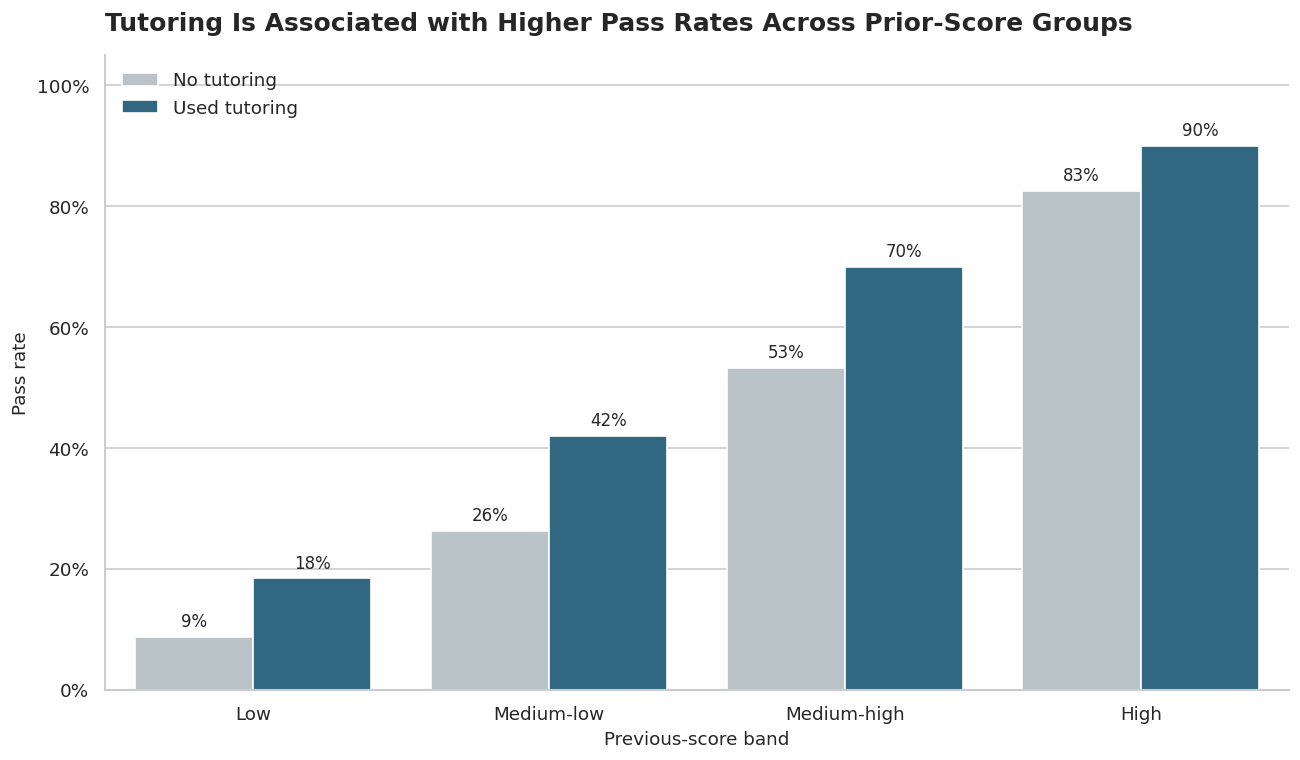

In [5]:
df["Previous_Score_Band"] = pd.qcut(
    df["Previous_Scores"],
    q=4,
    labels=band_order,
)
df["Tutoring_Group"] = np.where(
    df["Tutoring_Sessions"] > 0,
    "Used tutoring",
    "No tutoring",
)

support_summary = (
    df.groupby(["Previous_Score_Band", "Tutoring_Group"], observed=True)
    .agg(Pass_Rate=("Passed", "mean"), Students=("Passed", "size"))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 6.5))

sns.barplot(
    data=support_summary,
    x="Previous_Score_Band",
    y="Pass_Rate",
    hue="Tutoring_Group",
    hue_order=["No tutoring", "Used tutoring"],
    order=band_order,
    palette=["#B8C4C9", BLUE],
    edgecolor="white",
    ax=ax,
)

for container in ax.containers:
    ax.bar_label(container, labels=[f"{bar.get_height():.0%}" for bar in container], padding=4, fontsize=10)

ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
ax.set_title("Tutoring Is Associated with Higher Pass Rates Across Prior-Score Groups", loc="left", pad=15)
ax.set_xlabel("Previous-score band")
ax.set_ylabel("Pass rate")
ax.legend(title=None, frameon=False, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Story point:** Students who used tutoring had higher pass rates in all four previous-score bands. The largest differences appear in the middle groups, but the lowest prior-score group remains at high risk even with tutoring. This suggests that tutoring may be useful as part of a broader support strategy rather than as a complete solution by itself.

## Closing Narrative

The dataset shows a class close to the passing boundary: only a small majority pass, and the average score is almost equal to the threshold. Study time and attendance together are strongly associated with better results, with pass rates increasing from 20% to 84% across the lowest and highest behavioral groups. Previous performance also matters, but students who used tutoring show better outcomes within every prior-score band. Based on this exploratory story, a reasonable next step would be to identify students with low previous scores, weak attendance, and limited study time early, then offer targeted support and monitor whether their outcomes improve.

### Limitation

These visualizations summarize associations in a synthetic observational dataset. They do not prove that increasing study time, attendance, or tutoring directly causes higher exam scores. A real intervention would require additional data and a design that can evaluate causal effects.